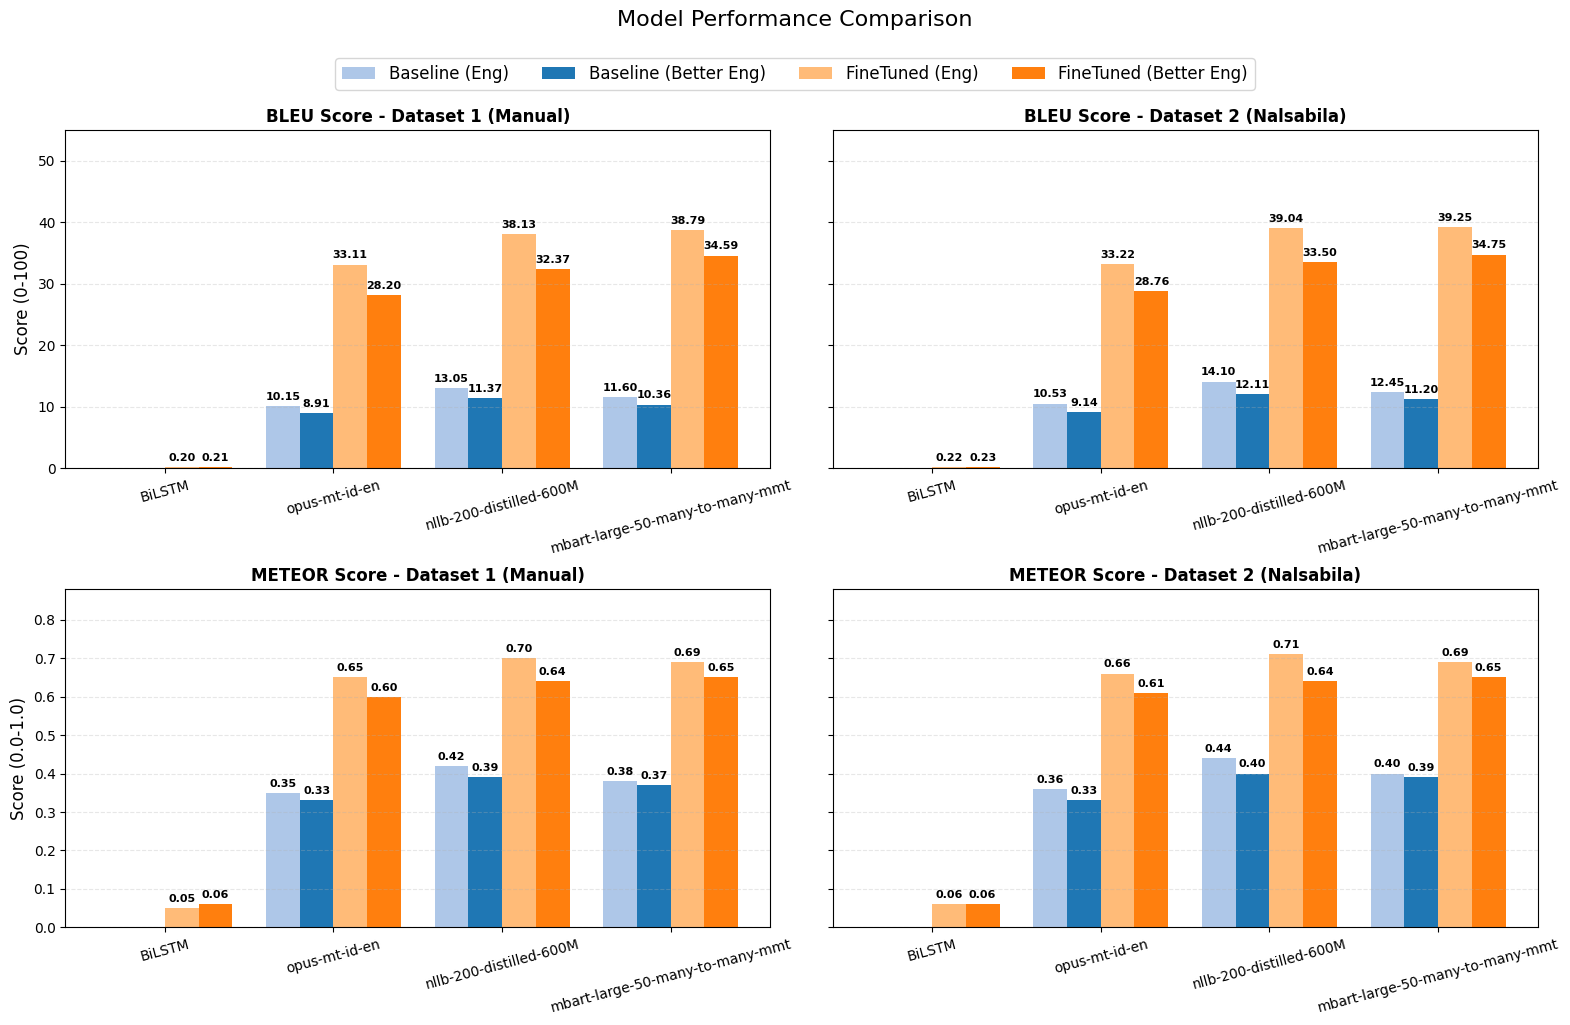

In [6]:
import matplotlib.pyplot as plt
import numpy as np

models = ['BiLSTM', 'opus-mt-id-en', 'nllb-200-distilled-600M', 'mbart-large-50-many-to-many-mmt']

# --- DATASET 1 (Manual) ---
d1_bleu_base_eng    = [0, 10.15, 13.05, 11.60]
d1_bleu_base_better = [0, 8.91, 11.37, 10.36]
d1_bleu_ft_eng      = [0.20, 33.11, 38.13, 38.79]
d1_bleu_ft_better   = [0.21, 28.20, 32.37, 34.59]

d1_meteor_base_eng    = [0, 0.35, 0.42, 0.38]
d1_meteor_base_better = [0, 0.33, 0.39, 0.37]
d1_meteor_ft_eng      = [0.05, 0.65, 0.70, 0.69]
d1_meteor_ft_better   = [0.06, 0.60, 0.64, 0.65]

# --- DATASET 2 (Nalsabila) ---
d2_bleu_base_eng    = [0, 10.53, 14.10, 12.45]
d2_bleu_base_better = [0, 9.14, 12.11, 11.20]
d2_bleu_ft_eng      = [0.22, 33.22, 39.04, 39.25]
d2_bleu_ft_better   = [0.23, 28.76, 33.50, 34.75]

d2_meteor_base_eng    = [0, 0.36, 0.44, 0.40]
d2_meteor_base_better = [0, 0.33, 0.40, 0.39]
d2_meteor_ft_eng      = [0.06, 0.66, 0.71, 0.69]
d2_meteor_ft_better   = [0.06, 0.61, 0.64, 0.65]

all_data = [
    [[d1_bleu_base_eng, d1_bleu_base_better, d1_bleu_ft_eng, d1_bleu_ft_better],
     [d2_bleu_base_eng, d2_bleu_base_better, d2_bleu_ft_eng, d2_bleu_ft_better]],
    [[d1_meteor_base_eng, d1_meteor_base_better, d1_meteor_ft_eng, d1_meteor_ft_better],
     [d2_meteor_base_eng, d2_meteor_base_better, d2_meteor_ft_eng, d2_meteor_ft_better]]
]

row_labels = ['BLEU Score', 'METEOR Score']
col_labels = ['Dataset 1 (Manual)', 'Dataset 2 (Nalsabila)']
bar_labels = ['Baseline (Eng)', 'Baseline (Better Eng)', 'FineTuned (Eng)', 'FineTuned (Better Eng)']
colors = ['#aec7e8', '#1f77b4', '#ffbb78', '#ff7f0e']

x = np.arange(len(models))
width = 0.2

# Limits
row_limits = [
    (0, 50),   # BLEU Limit
    (0, 0.8)   # METEOR Limit
]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10), sharey='row')

for r in range(2):
    for c in range(2):
        ax = axes[r, c]
        dataset_scores = all_data[r][c]

        for i, score_list in enumerate(dataset_scores):
            offset = (i - 1.5) * width
            rects = ax.bar(x + offset, score_list, width, label=bar_labels[i], color=colors[i])

            for rect in rects:
                height = rect.get_height()
                if height > 0:
                    ax.annotate(f'{height:.2f}',
                                xy=(rect.get_x() + rect.get_width() / 2, height),
                                xytext=(0, 3),  # 3 points vertical offset
                                textcoords="offset points",
                                ha='center', va='bottom', rotation=0, fontsize=8, fontweight='bold')

        ax.set_title(f"{row_labels[r]} - {col_labels[c]}", fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=15)
        ax.grid(axis='y', linestyle='--', alpha=0.3)

        # APPLY LIMITS
        current_limit = row_limits[r]
        ax.set_ylim(current_limit[0], current_limit[1] * 1.1)

        if c == 0:
            if r == 0:
                ax.set_ylabel("Score (0-100)", fontsize=12)
            else:
                ax.set_ylabel("Score (0.0-1.0)", fontsize=12)

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles[:4], labels[:4], loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=4, fontsize=12)

plt.suptitle("Model Performance Comparison", fontsize=16, y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

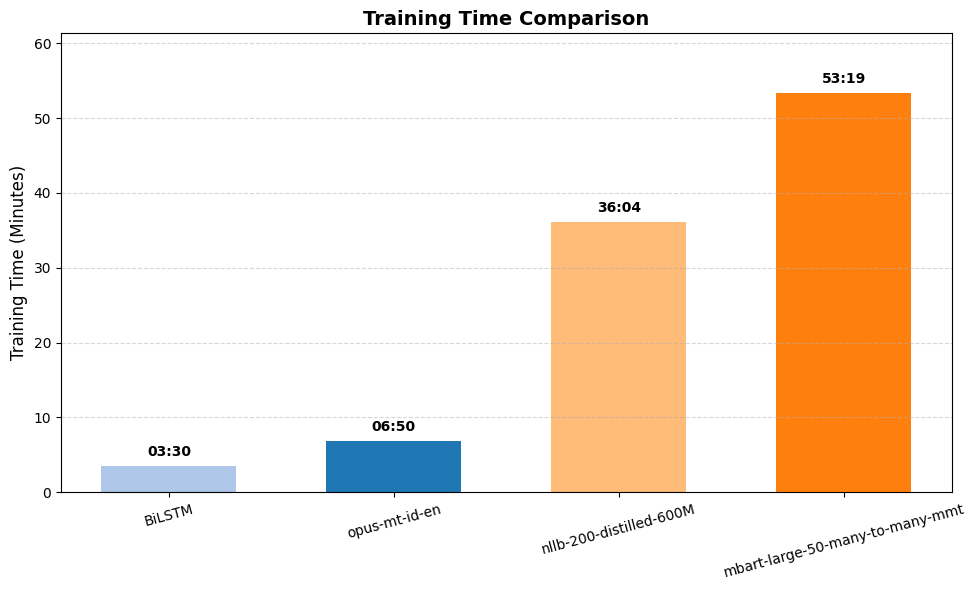

In [7]:
import matplotlib.pyplot as plt
import numpy as np

models = ['BiLSTM', 'opus-mt-id-en', 'nllb-200-distilled-600M', 'mbart-large-50-many-to-many-mmt']
raw_times = ['03:30', '06:50', '36:04', '53:19']

minutes_values = []

for t in raw_times:
    parts = t.split(':')
    m = int(parts[0])
    s = int(parts[1])
    minutes_values.append(m + s/60.0)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#aec7e8', '#1f77b4', '#ffbb78', '#ff7f0e']

bars = ax.bar(models, minutes_values, color=colors, width=0.6)

ax.set_ylabel('Training Time (Minutes)', fontsize=12)
ax.set_title('Training Time Comparison', fontsize=14, fontweight='bold')

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=15, ha='center')

for bar, raw_label in zip(bars, raw_times):
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{raw_label}",
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_ylim(0, max(minutes_values) * 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()